# 01 — Data

Anthropics [Economic Index](https://huggingface.co/datasets/Anthropic/EconomicIndex) classifies a sample of Claude conversations by which [O\*NET](https://www.onetonline.org/) occupational task they correspond to, and how the human and AI collaborated. Four releases span March 2025 to March 2026, with the schema expanding significantly in January 2026.

This notebook downloads the data, describes its structure, and constructs the task-level dataset we analyze.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import (
    download_all, load_unified_release, build_task_feature_matrix,
    RELEASE_FILES, AUTOMATION_MODES, AUGMENTATION_MODES,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150

In [2]:
paths = download_all()
print(f'{len(paths)} files downloaded from Anthropic/EconomicIndex')

19 files downloaded from Anthropic/EconomicIndex


## The four releases

The schema changed substantially across releases. Releases 1--2 contain only collaboration mode shares per task. Releases 3--4 add continuous measures: AI autonomy scores, human and AI education year estimates, time estimates, task success rates, and more.

In [3]:
releases = [
    ('Mar 2025', '../data/release_2025_03_27_automation_vs_augmentation_by_task.csv', None),
    ('Sep 2025', '../data/release_2025_09_15_data_intermediate_aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv', None),
    ('Jan 2026', '../data/release_2026_01_15_data_intermediate_aei_raw_claude_ai_2025-11-13_to_2025-11-20.csv', None),
    ('Mar 2026', '../data/release_2026_03_24_data_aei_raw_claude_ai_2026-02-05_to_2026-02-12.csv', None),
]

for label, path, _ in releases:
    df = pd.read_csv(path)
    if 'facet' in df.columns:
        n_facets = df['facet'].nunique()
        n_tasks = df[df['facet'].str.match(r'^onet_task$', na=False)]['cluster_name'].nunique()
        print(f'{label:10s}  {len(df):>8,} rows  {n_facets:>3} facets  {n_tasks:>5} tasks')
    else:
        print(f'{label:10s}  {len(df):>8,} rows  (flat schema, {len(df)} tasks)')

Mar 2025       3,364 rows  (flat schema, 3364 tasks)
Sep 2025     100,062 rows    7 facets   2618 tasks
Jan 2026     458,778 rows   34 facets   3170 tasks
Mar 2026     425,257 rows   34 facets   3260 tasks


## Collaboration modes

The core classification. Every Claude conversation is assigned one of five collaboration modes, which Anthropic groups into **automation** (the AI acts autonomously) and **augmentation** (the human stays in the loop).

| Mode | Category | The AI... |
|------|----------|----------|
| Directive | Automation | executes a complete task autonomously |
| Feedback loop | Automation | iterates toward a solution with minimal human input |
| Task iteration | Augmentation | drafts, then the human iterates |
| Validation | Augmentation | produces output that the human checks |
| Learning | Augmentation | teaches the human something |

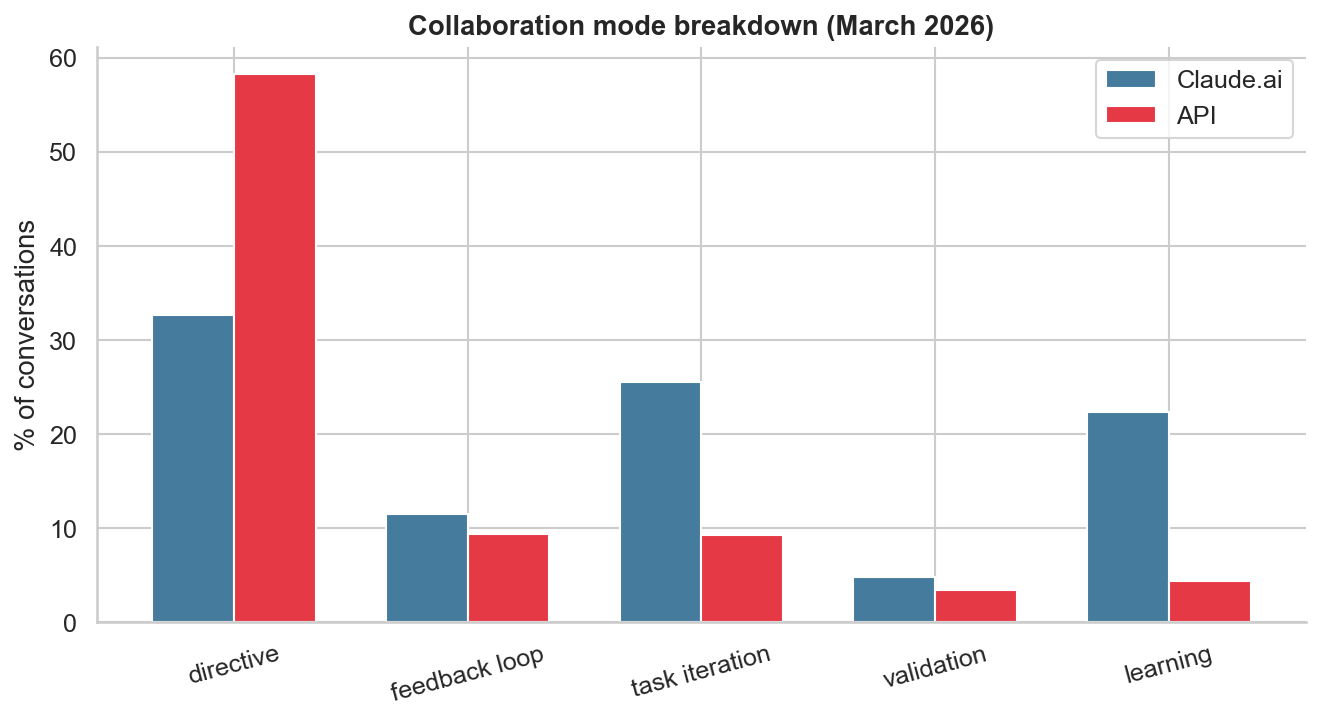

In [4]:
# Global collaboration breakdown: Claude.ai vs API
claude = load_unified_release('2026_03', platform='claude_ai')
api = load_unified_release('2026_03', platform='api')

def get_global_collab(df):
    m = (df['facet'] == 'collaboration') & (df['geography'] == 'global') & df['variable'].str.endswith('pct')
    return df[m].set_index('cluster_name')['value']

modes = ['directive', 'feedback loop', 'task iteration', 'validation', 'learning']
comp = pd.DataFrame({'Claude.ai': get_global_collab(claude), 'API': get_global_collab(api)}).reindex(modes)

fig, ax = plt.subplots(figsize=(9, 5))
x = range(len(comp))
w = 0.35
ax.bar([i - w/2 for i in x], comp['Claude.ai'], w, label='Claude.ai', color='#457B9D')
ax.bar([i + w/2 for i in x], comp['API'], w, label='API', color='#E63946')
ax.set_xticks(x)
ax.set_xticklabels(comp.index, rotation=15)
ax.set_ylabel('% of conversations')
ax.set_title('Collaboration mode breakdown (March 2026)', fontweight='bold')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('../figures/01_collaboration_modes.png', bbox_inches='tight')
plt.show()

## Constructing the task-level dataset

From the March 2026 release, we extract per-task measures and join them into a single row per task. Each of the 3,259 tasks gets:

- **Collaboration mode shares** (what fraction of conversations are directive, feedback loop, etc.)
- **AI autonomy score** (1--5, how independently the AI acts)
- **Human and AI education year estimates** (how many years of education each needs for the task)
- **Task success rate** (fraction of conversations rated successful)
- **O\*NET occupation mapping** (which SOC codes the task belongs to)

In [5]:
tasks = build_task_feature_matrix()
tu = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)

print(f'{len(tu):,} unique tasks')
print(f'{tasks["soc_code"].nunique()} occupations (via O*NET mapping)')
print()
cols = ['ai_autonomy_mean', 'automation_share', 'human_education_years',
        'ai_education_years', 'success_rate', 'human_only_ability_pct', 'conversation_count']
for c in cols:
    n = tu[c].notna().sum()
    print(f'  {c:30s}  {n:>5,} tasks  ({n/len(tu):.0%} coverage)')

3,259 unique tasks
566 occupations (via O*NET mapping)

  ai_autonomy_mean                3,259 tasks  (100% coverage)
  automation_share                3,259 tasks  (100% coverage)
  human_education_years           3,259 tasks  (100% coverage)
  ai_education_years              3,259 tasks  (100% coverage)
  success_rate                    2,739 tasks  (84% coverage)
  human_only_ability_pct          3,105 tasks  (95% coverage)
  conversation_count              3,259 tasks  (100% coverage)
